# 다중클래스분류_callback사용해_과적합_막고_최고성능모델_저장하기

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import koreanize_matplotlib

In [3]:
data = pd.read_csv("./data/winequality-white.csv", sep=";")
data.head()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
0,7.0,0.27,0.36,20.7,0.045,45.0,170.0,1.0010,3.00,0.45,8.8,6
1,6.3,0.30,0.34,1.6,0.049,14.0,132.0,0.9940,3.30,0.49,9.5,6
2,8.1,0.28,0.40,6.9,0.050,30.0,97.0,0.9951,3.26,0.44,10.1,6
3,7.2,0.23,0.32,8.5,0.058,47.0,186.0,0.9956,3.19,0.40,9.9,6
4,7.2,0.23,0.32,8.5,0.058,47.0,186.0,0.9956,3.19,0.40,9.9,6


In [4]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4898 entries, 0 to 4897
Data columns (total 12 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   fixed acidity         4898 non-null   float64
 1   volatile acidity      4898 non-null   float64
 2   citric acid           4898 non-null   float64
 3   residual sugar        4898 non-null   float64
 4   chlorides             4898 non-null   float64
 5   free sulfur dioxide   4898 non-null   float64
 6   total sulfur dioxide  4898 non-null   float64
 7   density               4898 non-null   float64
 8   pH                    4898 non-null   float64
 9   sulphates             4898 non-null   float64
 10  alcohol               4898 non-null   float64
 11  quality               4898 non-null   int64  
dtypes: float64(11), int64(1)
memory usage: 459.3 KB


<Axes: >

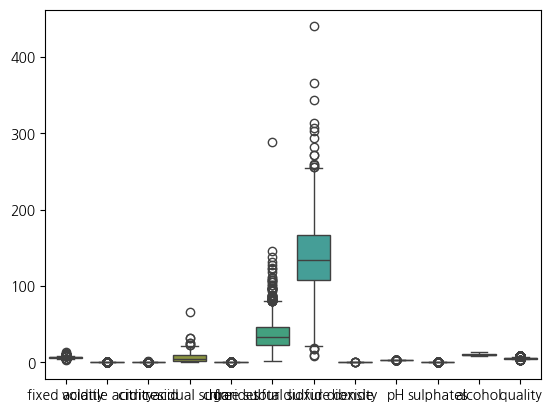

In [6]:
sns.boxplot(data)

In [7]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import RobustScaler

In [8]:
X = data.drop('quality', axis=1)
y = data['quality']

In [9]:
X

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol
0,7.0,0.27,0.36,20.7,0.045,45.0,170.0,1.00100,3.00,0.45,8.8
1,6.3,0.30,0.34,1.6,0.049,14.0,132.0,0.99400,3.30,0.49,9.5
2,8.1,0.28,0.40,6.9,0.050,30.0,97.0,0.99510,3.26,0.44,10.1
3,7.2,0.23,0.32,8.5,0.058,47.0,186.0,0.99560,3.19,0.40,9.9
4,7.2,0.23,0.32,8.5,0.058,47.0,186.0,0.99560,3.19,0.40,9.9
...,...,...,...,...,...,...,...,...,...,...,...
4893,6.2,0.21,0.29,1.6,0.039,24.0,92.0,0.99114,3.27,0.50,11.2
4894,6.6,0.32,0.36,8.0,0.047,57.0,168.0,0.99490,3.15,0.46,9.6
4895,6.5,0.24,0.19,1.2,0.041,30.0,111.0,0.99254,2.99,0.46,9.4
4896,5.5,0.29,0.30,1.1,0.022,20.0,110.0,0.98869,3.34,0.38,12.8


In [10]:
y

0       6
1       6
2       6
3       6
4       6
       ..
4893    6
4894    5
4895    6
4896    7
4897    6
Name: quality, Length: 4898, dtype: int64

In [11]:
y = pd.get_dummies(y)
y

,3,4,5,6,7,8,9
0,False,False,False,True,False,False,False
1,False,False,False,True,False,False,False
2,False,False,False,True,False,False,False
3,False,False,False,True,False,False,False
4,False,False,False,True,False,False,False
...,...,...,...,...,...,...,...
4893,False,False,False,True,False,False,False
4894,False,False,True,False,False,False,False
4895,False,False,False,True,False,False,False
4896,False,False,False,False,True,False,False


In [12]:
data['quality'].value_counts()

quality
6    2198
5    1457
7     880
8     175
4     163
3      20
9       5
Name: count, dtype: int64

In [13]:
X_train, X_valid, y_train, y_valid = train_test_split(X, y, test_size=0.4, stratify=y)
X_valid, X_test, y_valid, y_test = train_test_split(X_valid, y_valid, test_size=0.5, stratify=y_valid)

In [14]:
rs = RobustScaler()
train_temp = rs.fit_transform(X_train)
valid_temp = rs.transform(X_valid)
test_temp = rs.transform(X_test)
rs_X_train = pd.DataFrame(train_temp, columns=X_train.columns, index=X_train.index)
rs_X_valid = pd.DataFrame(valid_temp, columns=X_valid.columns, index=X_valid.index)
rs_X_test = pd.DataFrame(test_temp, columns=X_test.columns, index=X_test.index)

# 모델을 최고 성능에서 저장하고 중지하기

In [15]:
from keras.models import Sequential
from keras.layers import Dense, Input
from keras.callbacks import EarlyStopping, ModelCheckpoint

In [18]:
model = Sequential()
model.add(Input(shape=(rs_X_train.shape[1],)))
model.add(Dense(64, activation='relu'))
model.add(Dense(32, activation='relu'))
model.add(Dense(16, activation='relu'))
model.add(Dense(7, activation='softmax'))
model.summary()

I0000 00:00:1747284571.024507    9427 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 1347 MB memory:  -> device: 0, name: NVIDIA GeForce MX450, pci bus id: 0000:01:00.0, compute capability: 7.5


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 64)             │           768 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 7)              │           119 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,495 (13.65 KB)

 Trainable params: 3,495 (13.65 KB)

 Non-trainable params: 0 (0.00 B)

In [19]:
import os

Epoch 1/1000


I0000 00:00:1747286362.997901    9523 service.cc:152] XLA service 0x7f0ef00055d0 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1747286362.997944    9523 service.cc:160]   StreamExecutor device (0): NVIDIA GeForce MX450, Compute Capability 7.5
2025-05-15 14:19:23.034449: I tensorflow/compiler/mlir/tensorflow/utils/dump_mlir_util.cc:269] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
I0000 00:00:1747286363.236685    9523 cuda_dnn.cc:529] Loaded cuDNN version 90300


40/92 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.2198 - loss: 1.8530

I0000 00:00:1747286365.019816    9523 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


92/92 ━━━━━━━━━━━━━━━━━━━━ 6s 35ms/step - accuracy: 0.3013 - loss: 1.7014 - val_accuracy: 0.4939 - val_loss: 1.2763
Epoch 2/1000
92/92 ━━━━━━━━━━━━━━━━━━━━ -1s -11860us/step - accuracy: 0.5134 - loss: 1.2193 - val_accuracy: 0.5449 - val_loss: 1.1597
Epoch 3/1000
92/92 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.5596 - loss: 1.1259 - val_accuracy: 0.5561 - val_loss: 1.1047
Epoch 4/1000
92/92 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.5544 - loss: 1.0925 - val_accuracy: 0.5561 - val_loss: 1.0883
Epoch 5/1000
92/92 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.5625 - loss: 1.0597 - val_accuracy: 0.5561 - val_loss: 1.0765
Epoch 6/1000
92/92 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.5700 - loss: 1.0438 - val_accuracy: 0.5510 - val_loss: 1.0795
Epoch 7/1000
92/92 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.5927 - loss: 1.0105 - val_accuracy: 0.5643 - val_loss: 1.0635
Epoch 8/1000
92/92 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.5819 - loss: 1.0158 - val_accuracy: 0.5622 -

92/92 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.6711 - loss: 0.7937 - val_accuracy: 0.5480 - val_loss: 1.1091
Epoch 52/1000
92/92 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - accuracy: 0.6903 - loss: 0.7631 - val_accuracy: 0.5286 - val_loss: 1.1114
Epoch 53/1000
92/92 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - accuracy: 0.6950 - loss: 0.7555 - val_accuracy: 0.5469 - val_loss: 1.1088
Epoch 54/1000
92/92 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.6755 - loss: 0.7728 - val_accuracy: 0.5398 - val_loss: 1.1215
Epoch 55/1000
92/92 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.6820 - loss: 0.7657 - val_accuracy: 0.5408 - val_loss: 1.1336
Epoch 56/1000
92/92 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - accuracy: 0.6711 - loss: 0.8005 - val_accuracy: 0.5520 - val_loss: 1.1101
Epoch 57/1000
92/92 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.6915 - loss: 0.7483 - val_accuracy: 0.5337 - val_loss: 1.1386
Epoch 58/1000
92/92 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.6795 - loss: 0.7666 - val_accuracy: 0.558

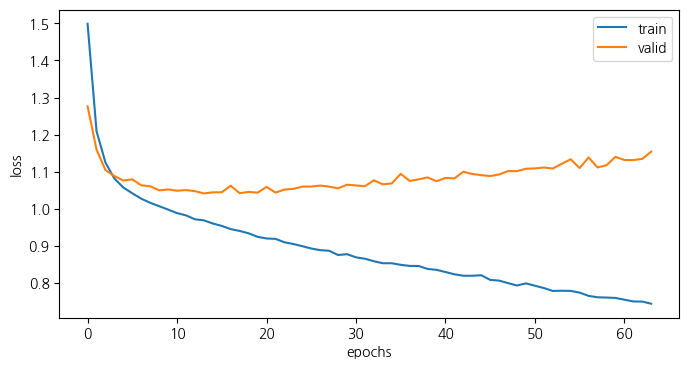

In [23]:
model.compile(loss='categorical_crossentropy', optimizer='adam', metrics=['accuracy'])
early_stop = EarlyStopping(patience=50)
os.makedirs("./model", exist_ok=True) # 디렉토리 자동 생성
filepath = "./model/whitewine_{epoch:04d}__{val_loss:.4f}.keras"
model_save = ModelCheckpoint(filepath=filepath, save_best_only=True)
history = model.fit(rs_X_train, y_train,
                   epochs=1000,
                   batch_size=32,
                   validation_data=(rs_X_valid, y_valid),
                   callbacks=[early_stop, model_save])
plt.figure(figsize=(8,4))
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.xlabel("epochs")
plt.ylabel("loss")
plt.legend(['train', 'valid'])
plt.show()

# 데이터 증폭 후 분석
* 데이터 증폭 + 스케일러 사용시
* 데이터 증폭 후 스케일러로 스케일링

In [24]:
from imblearn.over_sampling import SMOTE

In [25]:
X_train, X_valid, y_train, y_valid = train_test_split(X, y, test_size=0.4, stratify=y)
X_valid, X_test, y_valid, y_test = train_test_split(X_valid, y_valid, test_size=0.5, stratify=y_valid)

In [ ]:
smt = SMOTE()

In [14]:
rs = RobustScaler()
train_temp = rs.fit_transform(X_train)
valid_temp = rs.transform(X_valid)
test_temp = rs.transform(X_test)
rs_X_train = pd.DataFrame(train_temp, columns=X_train.columns, index=X_train.index)
rs_X_valid = pd.DataFrame(valid_temp, columns=X_valid.columns, index=X_valid.index)
rs_X_test = pd.DataFrame(test_temp, columns=X_test.columns, index=X_test.index)